# IMPORTS

In [9]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

# LOAD I CLEAN DANYCH

In [10]:
df = pd.read_csv('../data/raw.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df =df.dropna(subset=['TotalCharges'])
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# TARGET I FEATURES

In [11]:
X = df.drop(columns=['customerID', 'Churn'])
y = df['Churn'].map({'Yes': 1, 'No': 0})

# PODZIAŁ NA NUM/CAT

In [12]:
num_features = X.select_dtypes(include=['int64', 'float64']).columns.to_list()
cat_features = X.select_dtypes(include=['object']).columns.to_list()

num_features, cat_features

/var/folders/38/dzyxx1mn1071xyjg93b0_v880000gn/T/ipykernel_16139/59699483.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X.select_dtypes(include=['object']).columns.to_list()


(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'],
 ['gender',
  'Partner',
  'Dependents',
  'PhoneService',
  'MultipleLines',
  'InternetService',
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport',
  'StreamingTV',
  'StreamingMovies',
  'Contract',
  'PaperlessBilling',
  'PaymentMethod'])

# TRAIN/TEST SPLIT

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# PREPROCESING PIPELINE

In [14]:
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features)
    ]
)

# BASELINE – LOGISTIC REGRESSION

In [23]:
lr_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

lr_pipeline.fit(X_train, y_train)

lr_pred = lr_pipeline.predict_proba(X_test)[:, 1]

roc_auc_lr = roc_auc_score(y_test, lr_pred)

roc_auc_lr

0.8359290473207676

# RANDOM FOREST

In [16]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(random_state=42))
    ]
)

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict_proba(X_test)[:, 1]

roc_auc_rf = roc_auc_score(y_test, rf_pred)

roc_auc_rf

0.8133273110353004

# PORÓWNANIE MODELI

In [19]:
results = pd.Series({
    "Logistic Regression": roc_auc_lr,
    "Random Forest": roc_auc_rf
    }).sort_values(ascending=False)

print(results.index[0])

Logistic Regression


# CONFUSION MATRIX

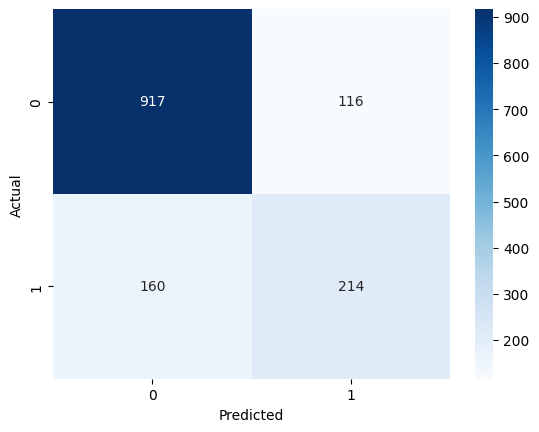

In [25]:
best_model = lr_pipeline 
y_pred_class = best_model.predict(X_test)
confusion_matrix = confusion_matrix(y_test, y_pred_class)
sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Model Comparison

Logistic Regression ROC AUC: 0.83 
Random Forest ROC AUC: 0.81

Logistic Regression achieved better performance and will be selected as the production model.